In [ ]:
from pathlib import Path
import sys

PROJECT_ROOT = next(
    (path for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
     if (path / "scripts").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not find the repository scripts directory.")

SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

V3LE_ROOT = Path("/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3LE_paper")
V3LE_FIG_ROOT = V3LE_ROOT / "figures"
V3LE_DIAG_DIR = V3LE_ROOT / "diag_data"
FIG_DIR_ROOT = V3LE_FIG_ROOT / "time_series_imsk"

In [3]:
import os
import re
import numpy as np
import pandas as pd
import xarray as xr
from collections import OrderedDict
from typing import Optional, Tuple, Set
from xarray.coders import CFDatetimeCoder

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.dates import AutoDateLocator, AutoDateFormatter
from collections import OrderedDict
import matplotlib.dates as mdates

# --- Imports
from pathlib import Path    
from data_utils import (
    REFERENCE_VAR_DICT,
    define_region,
    list_regions, 
    gen_land_mask, 
    gen_ice_mask,
    normalize_longitude,
    get_run_meta,
    list_runs,
    get_var_meta,
    get_levels,
)

In [4]:
class AnnualAnomalyFigurePlotter:
    """
    Phase B: read precomputed stats NetCDF and render multi-panel figures.
    Columns: original, detrended (optional), and ensemble-anomaly (spread around zero).
    Expects vars: <base>_mean/_std/_min/_max/_p05/_p95 (+ *_detr).
    """

    def __init__(self, stats_ds_or_path, var_dict, season="ANN", fontz=12, fig_dir=None):
        self.var_dict = var_dict or {}
        self.season   = season
        self.fontz    = fontz
        self.fig_dir  = fig_dir or "."

        # attach stats
        if isinstance(stats_ds_or_path, xr.Dataset):
            self.ds = stats_ds_or_path
        else:
            self.ds = xr.open_dataset(str(stats_ds_or_path))

        # time coord
        if "time" in self.ds.dims:
            self.time_coord = "time"
        elif "year" in self.ds.dims:
            self.time_coord = "year"
        else:
            raise ValueError("Stats file lacks a 'time' or 'year' dimension.")

        # numeric x (handles cftime 360_day / no_leap / all_leap / gregorian)
        self.x = self._to_numeric_time(self.ds[self.time_coord]).astype(float)

        # read saved provenance (percentiles)
        self.meta = {}
        try:
            prov = self.ds.attrs.get("annual_anomaly_plotter", "")
            if prov:
                self.meta = json.loads(prov)
        except Exception:
            self.meta = {}
        saved_pct = self.meta.get("pct_band", [5, 95])
        try:
            self.saved_pct_band = (int(saved_pct[0]), int(saved_pct[1]))
        except Exception:
            self.saved_pct_band = (5, 95)

    # ---- time helpers ----
    def _to_numeric_time(self, tcoord):
        vals = np.asarray(getattr(tcoord, "values", tcoord))
        # already numeric?
        if np.issubdtype(vals.dtype, np.number):
            return vals.astype(float)
        # cftime-like? (objects with .year and .timetuple)
        if vals.size and hasattr(vals.flat[0], "year") and hasattr(vals.flat[0], "timetuple"):
            years = np.array([int(v.year) for v in vals], dtype=float)
            doy   = np.array([v.timetuple().tm_yday for v in vals], dtype=float)
            cls   = type(vals.flat[0]).__name__
            if "360" in cls:
                denom = 360.0
                return years + (doy - 1.0) / denom
            if "AllLeap" in cls:
                denom = 366.0
                return years + (doy - 1.0) / denom
            if "NoLeap" in cls:
                denom = 365.0
                return years + (doy - 1.0) / denom
            # per-year leap rule (Gregorian) without imports
            def _is_leap(y):
                return (y % 4 == 0 and y % 100 != 0) or (y % 400 == 0)
            den = np.array([366.0 if _is_leap(int(y)) else 365.0 for y in years], dtype=float)
            return years + (doy - 1.0) / den
        # fallback: try pandas-like conversion
        try:
            tt = pd.to_datetime(vals)
            years = tt.year.astype(float)
            doy   = tt.dayofyear.astype(float)
            den   = np.where(getattr(tt, "is_leap_year", False), 366.0, 365.0).astype(float)
            return years + (doy - 1.0) / den
        except Exception:
            # last resort: simple index
            return np.arange(getattr(tcoord, "size", len(vals)), dtype=float)

    # ---- data access ----
    def _get(self, base, name, detr=False):
        key = f"{base}_{name}" + ("_detr" if detr else "")
        if key not in self.ds:
            available = [k for k in self.ds.data_vars if k.startswith(f"{base}_")]
            raise KeyError(f"Missing variable in stats file: {key}. Available for '{base}': {available}")
        return self.ds[key]

    # ---- draw helpers ----
    def _draw_one(
        self, ax, var_name, *,
        spread, sigma, pct_band, use_detr,
        line_color, fill_color,
        whiskers, whisker_pct, whisker_color, whisker_alpha, whisker_linewidth, whisker_hatch,
        rolling
    ):
        meta = self.var_dict.get(var_name, {})
        mean = self._get(var_name, "mean", detr=use_detr)

        # band
        if spread == "std":
            std = self._get(var_name, "std", detr=use_detr)
            lo  = mean - float(sigma) * std
            hi  = mean + float(sigma) * std
            band_label = f"±{sigma}σ"
        else:
            lo_name = f"p{int(pct_band[0]):02d}"
            hi_name = f"p{int(pct_band[1]):02d}"
            try:
                lo = self._get(var_name, lo_name, detr=use_detr)
                hi = self._get(var_name, hi_name, detr=use_detr)
                band_label = f"{pct_band[0]}–{pct_band[1]}% band"
            except KeyError:
                fb = self.saved_pct_band
                lo = self._get(var_name, f"p{int(fb[0]):02d}", detr=use_detr)
                hi = self._get(var_name, f"p{int(fb[1]):02d}", detr=use_detr)
                band_label = f"{fb[0]}–{fb[1]}% band (saved)"

        y_mean = np.asarray(mean.values, dtype=float)
        y_lo   = np.asarray(lo.values,   dtype=float)
        y_hi   = np.asarray(hi.values,   dtype=float)
        m = np.isfinite(self.x) & np.isfinite(y_mean) & np.isfinite(y_lo) & np.isfinite(y_hi)

        # whiskers
        if whiskers in ("minmax", "pct"):
            if whiskers == "minmax":
                w_lo = np.asarray(self._get(var_name, "min", detr=use_detr).values, dtype=float)
                w_hi = np.asarray(self._get(var_name, "max", detr=use_detr).values, dtype=float)
                w_lbl = "Min/Max"
            else:
                w_pct = tuple(int(x) for x in whisker_pct)
                w_lo_name = f"p{w_pct[0]:02d}"; w_hi_name = f"p{w_pct[1]:02d}"
                try:
                    w_lo = np.asarray(self._get(var_name, w_lo_name, detr=use_detr).values, dtype=float)
                    w_hi = np.asarray(self._get(var_name, w_hi_name, detr=use_detr).values, dtype=float)
                    w_lbl = f"{w_pct[0]}–{w_pct[1]}% range"
                except KeyError:
                    sp = self.saved_pct_band
                    w_lo = np.asarray(self._get(var_name, f"p{int(sp[0]):02d}", detr=use_detr).values, dtype=float)
                    w_hi = np.asarray(self._get(var_name, f"p{int(sp[1]):02d}", detr=use_detr).values, dtype=float)
                    w_lbl = f"{sp[0]}–{sp[1]}% range (saved)"
            mw = np.isfinite(self.x) & np.isfinite(w_lo) & np.isfinite(w_hi)
            ax.fill_between(
                self.x[mw], w_lo[mw], w_hi[mw],
                facecolor=whisker_color, edgecolor=whisker_color,
                linewidth=whisker_linewidth, alpha=whisker_alpha,
                hatch=whisker_hatch, rasterized=True, label=w_lbl, zorder=-20
            )

        # main band + mean
        ax.fill_between(
            self.x[m], y_lo[m], y_hi[m],
            facecolor=fill_color, edgecolor=fill_color,
            alpha=whisker_alpha * 0.5, label=band_label, zorder=1
        )
        ax.plot(self.x[m], y_mean[m], color=line_color, linewidth=2, zorder=4, label="Mean")
        ax.plot(self.x[m], y_lo[m],  color=fill_color, linewidth=whisker_linewidth, zorder=1)
        ax.plot(self.x[m], y_hi[m],  color=fill_color, linewidth=whisker_linewidth, zorder=1)

        if meta.get("unit"):
            ax.set_ylabel(f"[{meta['unit']}]", fontsize=self.fontz)
        ax.grid(True, alpha=0.4)
        if meta.get("name"):
            ax.set_title(meta["name"], loc="left", fontsize=self.fontz*1.02, pad=6)
        rt = f"{self.season} ({'Detrended' if use_detr else 'Original'})"
        ax.set_title(rt, loc="right", fontsize=self.fontz*1.02, pad=6)

        return ax.get_legend_handles_labels()

    # ---- main API ----
    def plot(
        self,
        sub_dict,
        *,
        spread="std", sigma=1.0, pct_band=(5, 95),
        separate_panels=True, use_detrended=True, add_ensanom=True,
        dpi=300, fig_width=16.0, panel_height=3.0,
        row_space=0.6, col_space=0.4,
        line_color="black", fill_color="red",
        whiskers="minmax", whisker_pct=(5, 95), whisker_color="black",
        whisker_alpha=0.15, whisker_linewidth=0.8, whisker_hatch="",
        ylim="bounds", xlim=None, sharey=False, xlabels="all",
        out_path=None, main_title=False
    ):
        vars_to_plot = list(sub_dict.keys())
        col_modes = ["orig"] + (["detr"] if use_detrended else []) + (["ensanom"] if add_ensanom else [])
        nrows = len(vars_to_plot) if separate_panels else 1
        ncols = len(col_modes)

        fig_width_eff = fig_width if ncols > 1 else fig_width * 0.75
        fig, axes = plt.subplots(
            nrows=nrows, ncols=ncols,
            figsize=(fig_width_eff, panel_height * nrows),
            squeeze=False, sharex='col', sharey=sharey
        )
        fig.subplots_adjust(hspace=row_space, wspace=col_space)

        for i, v in enumerate(vars_to_plot):
            row = i if separate_panels else 0
            meta = sub_dict[v]
            for j, mode in enumerate(col_modes):
                ax = axes[row, j]
                if mode == "ensanom":
                    # centered at zero; spread from original stats
                    if spread == "std":
                        std = self._get(v, "std", detr=False).values.astype(float)
                        y_lo = -float(sigma) * std
                        y_hi = +float(sigma) * std
                        y_mean = np.zeros_like(std)
                        band_label = f"±{sigma}σ"
                    else:
                        lo_name = f"p{int(pct_band[0]):02d}"
                        hi_name = f"p{int(pct_band[1]):02d}"
                        try:
                            plo = self._get(v, lo_name, detr=False).values.astype(float)
                            phi = self._get(v, hi_name, detr=False).values.astype(float)
                            band_label = f"{pct_band[0]}–{pct_band[1]}% band"
                        except KeyError:
                            fb = self.saved_pct_band
                            plo = self._get(v, f"p{int(fb[0]):02d}", detr=False).values.astype(float)
                            phi = self._get(v, f"p{int(fb[1]):02d}", detr=False).values.astype(float)
                            band_label = f"{fb[0]}–{fb[1]}% band (saved)"
                        y_lo = -np.abs(plo)
                        y_hi =  np.abs(phi)
                        y_mean = np.zeros_like(plo)

                    m = np.isfinite(self.x) & np.isfinite(y_lo) & np.isfinite(y_hi)
                    ax.fill_between(self.x[m], y_lo[m], y_hi[m],
                                    facecolor=fill_color, edgecolor=fill_color,
                                    alpha=whisker_alpha * 0.5, label=band_label, zorder=1)
                    ax.plot(self.x[m], y_mean[m], color=line_color, linewidth=2, zorder=4, label="Mean=0")
                    ax.axhline(0, color="k", linewidth=0.8, alpha=0.35, zorder=0)

                    if isinstance(ylim, str) and ylim == "symmetric":
                        vec = np.concatenate([y_lo[np.isfinite(y_lo)], y_hi[np.isfinite(y_hi)]]).ravel() \
                              if (np.isfinite(y_lo).any() or np.isfinite(y_hi).any()) else np.array([1.0])
                        yabs = float(np.nanmax(np.abs(vec)))
                        ax.set_ylim(-yabs, yabs)

                    if meta.get("unit"):
                        ax.set_ylabel(f"[{meta['unit']}]", fontsize=self.fontz)
                    ax.grid(True, alpha=0.4)
                    ax.set_title(meta.get("name", v), loc="left", fontsize=self.fontz*1.02, pad=6)
                    ax.set_title(f"{self.season} (Member–EnsMean)", loc="right", fontsize=self.fontz*1.02, pad=6)

                else:
                    handles, labels = self._draw_one(
                        ax, v,
                        spread=spread, sigma=sigma, pct_band=pct_band, use_detr=(mode == "detr"),
                        line_color=line_color, fill_color=fill_color,
                        whiskers=whiskers, whisker_pct=whisker_pct, whisker_color=whisker_color,
                        whisker_alpha=whisker_alpha, whisker_linewidth=whisker_linewidth, whisker_hatch=whisker_hatch,
                        rolling=None
                    )
                    if isinstance(ylim, str) and ylim == "bounds":
                        vmin = meta.get("dmin" if mode == "detr" else "min", None)
                        vmax = meta.get("dmax" if mode == "detr" else "max", None)
                        if (vmin is not None) and (vmax is not None):
                            ax.set_ylim(vmin, vmax)
                            
                if xlim is not None:
                    xmin,xmax=xlim
                    ax.set_xlim(xmin, xmax)
                    
        # legends: first column of each row
        for i, _v in enumerate(vars_to_plot):
            row = i if separate_panels else 0
            ax0 = axes[row, 0]
            h, l = ax0.get_legend_handles_labels()
            if h:
                ax0.legend(h, l, frameon=True, fontsize=self.fontz * 0.95,
                           ncol=min(3, len(l)), loc="best")

        # x labels policy
        ax_all = axes.ravel()
        if xlabels == "all":
            for ax in ax_all:
                ax.tick_params(labelbottom=True)
                ax.set_xlabel(self.time_coord.capitalize(), fontsize=self.fontz)
        elif xlabels == "none":
            for ax in ax_all:
                ax.tick_params(labelbottom=False)
                ax.set_xlabel("")
        else:  # bottom only
            for ax in ax_all[:-ncols]:
                ax.tick_params(labelbottom=False)
            for ax in ax_all[-ncols:]:
                ax.set_xlabel(self.time_coord.capitalize(), fontsize=self.fontz)

        # x ticks (use numeric self.x to avoid cftime issues)
        years = self.x
        y0 = int(np.floor(np.nanmin(years))); y1 = int(np.ceil(np.nanmax(years)))
        span = max(1, y1 - y0)
        step = 1
        for cand in (1, 2, 5, 10, 20, 25, 50, 100):
            if span / cand <= 10:
                step = cand
                break
        ticks = np.arange(y0 - (y0 % step), y1 + 1, step)
        for ax in ax_all:
            ax.set_xticks(ticks)
            ax.set_xticklabels([str(int(t)) for t in ticks])

        # title & save
        if main_title:
            title_bits = ["Annual anomalies: ensemble mean",
                          ("±σ" if spread == "std" else f"{self.saved_pct_band[0]}–{self.saved_pct_band[1]}% band")]
            fig.suptitle(" ".join(title_bits), fontsize=self.fontz * 1.05)
            fig.tight_layout(rect=[0, 0, 1, 0.96])
        else:
            fig.tight_layout()

        if out_path:
            Path(out_path).parent.mkdir(parents=True, exist_ok=True)
            fig.savefig(out_path, dpi=dpi)
            plt.show()
            print(f"[INFO] Saved: {out_path}")

        return fig, axes


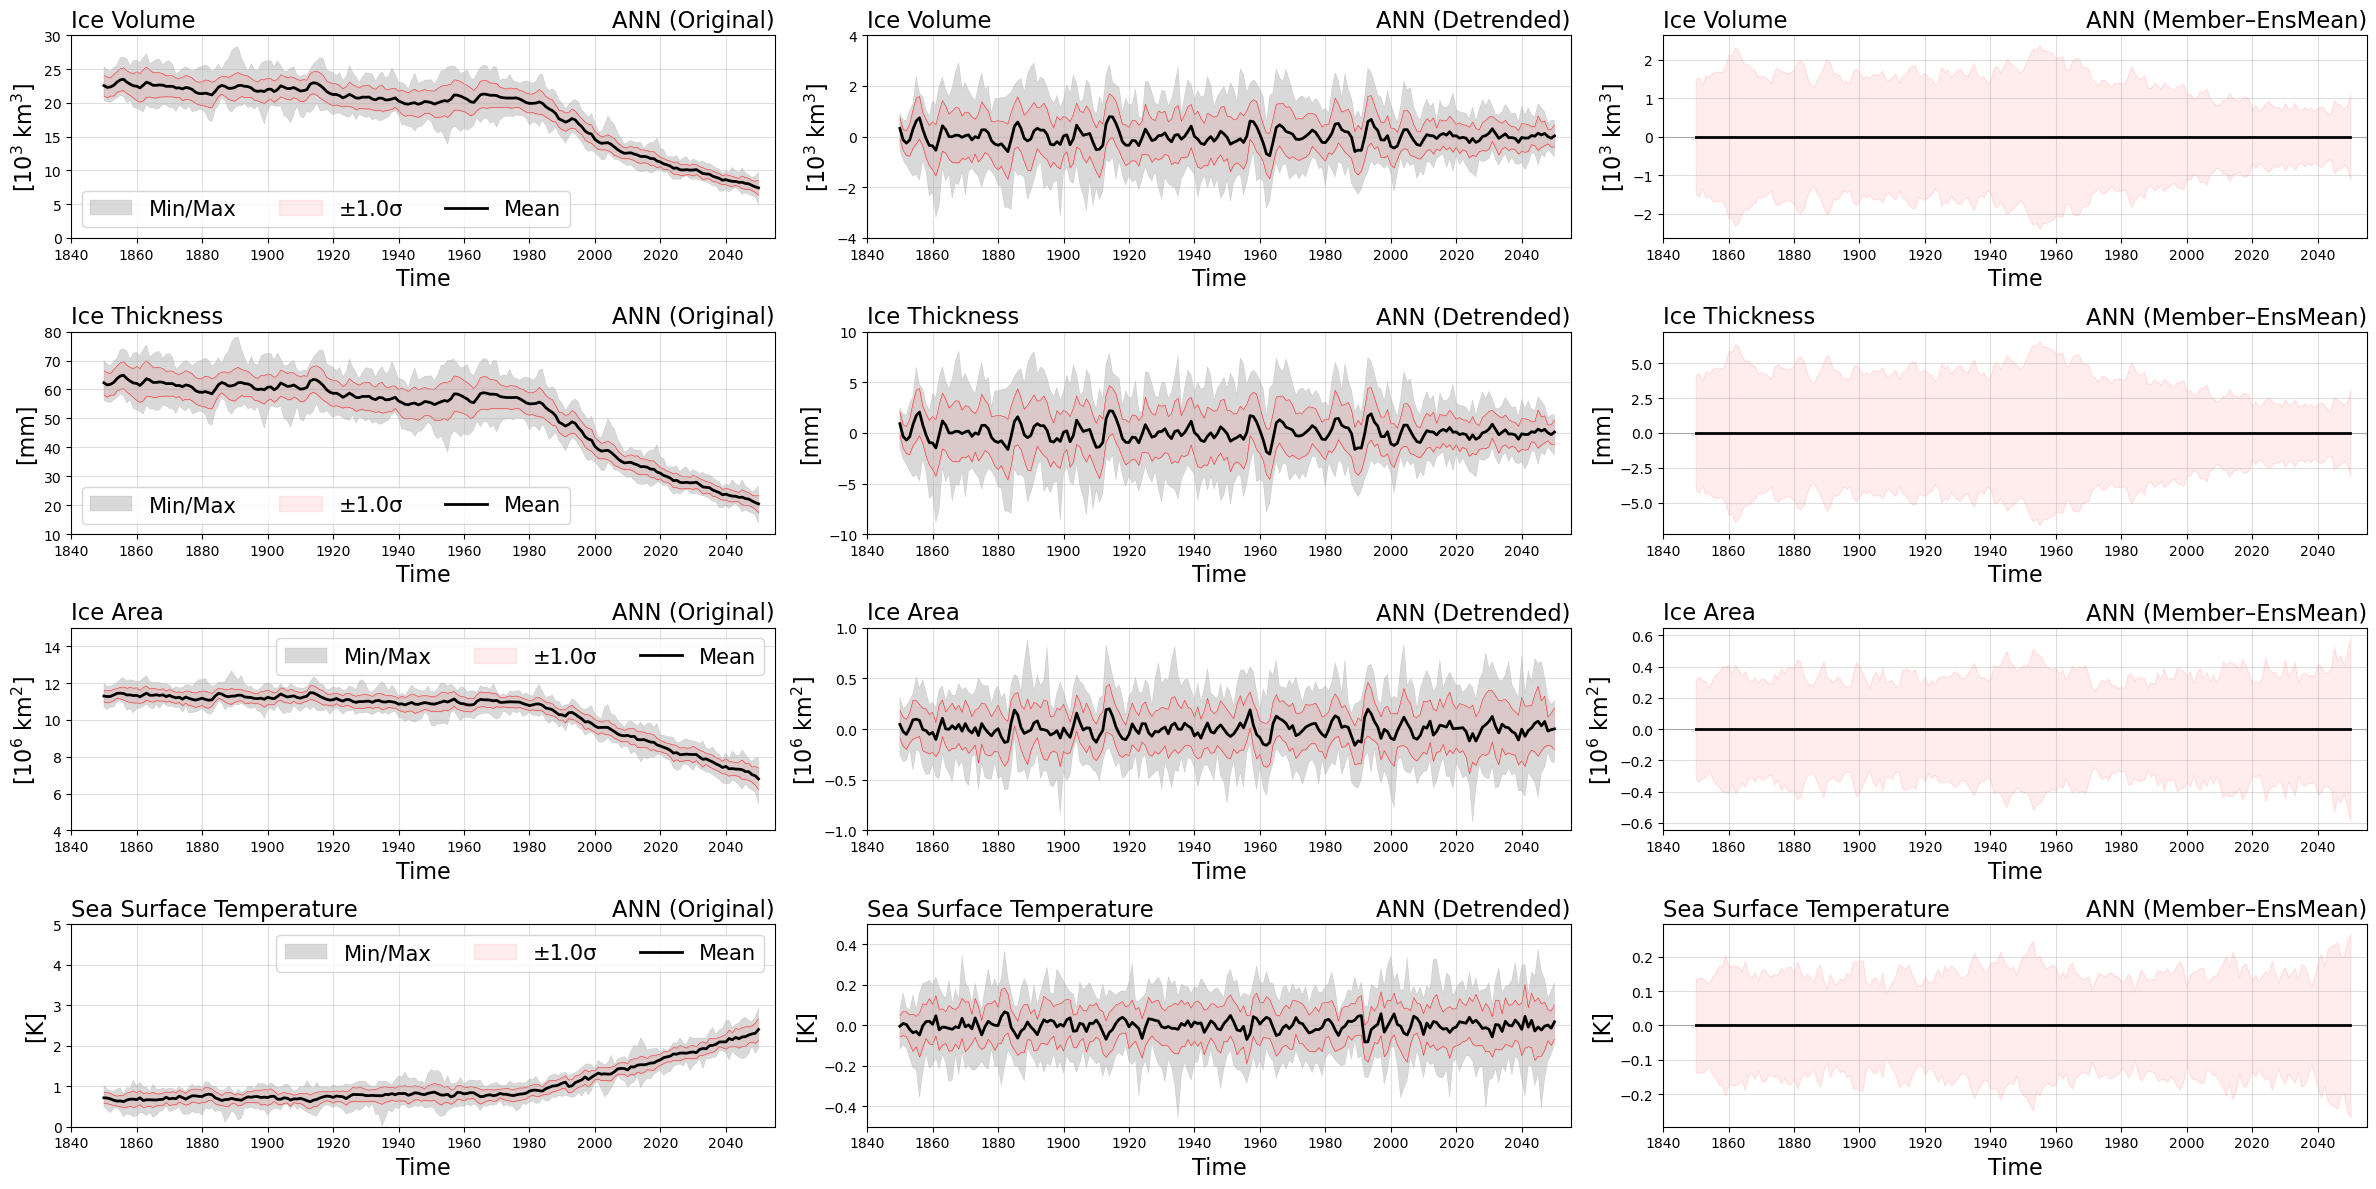

[INFO] Saved: v3.LR.historical.Arctic.ANN.185001-205012.nens25.pdf


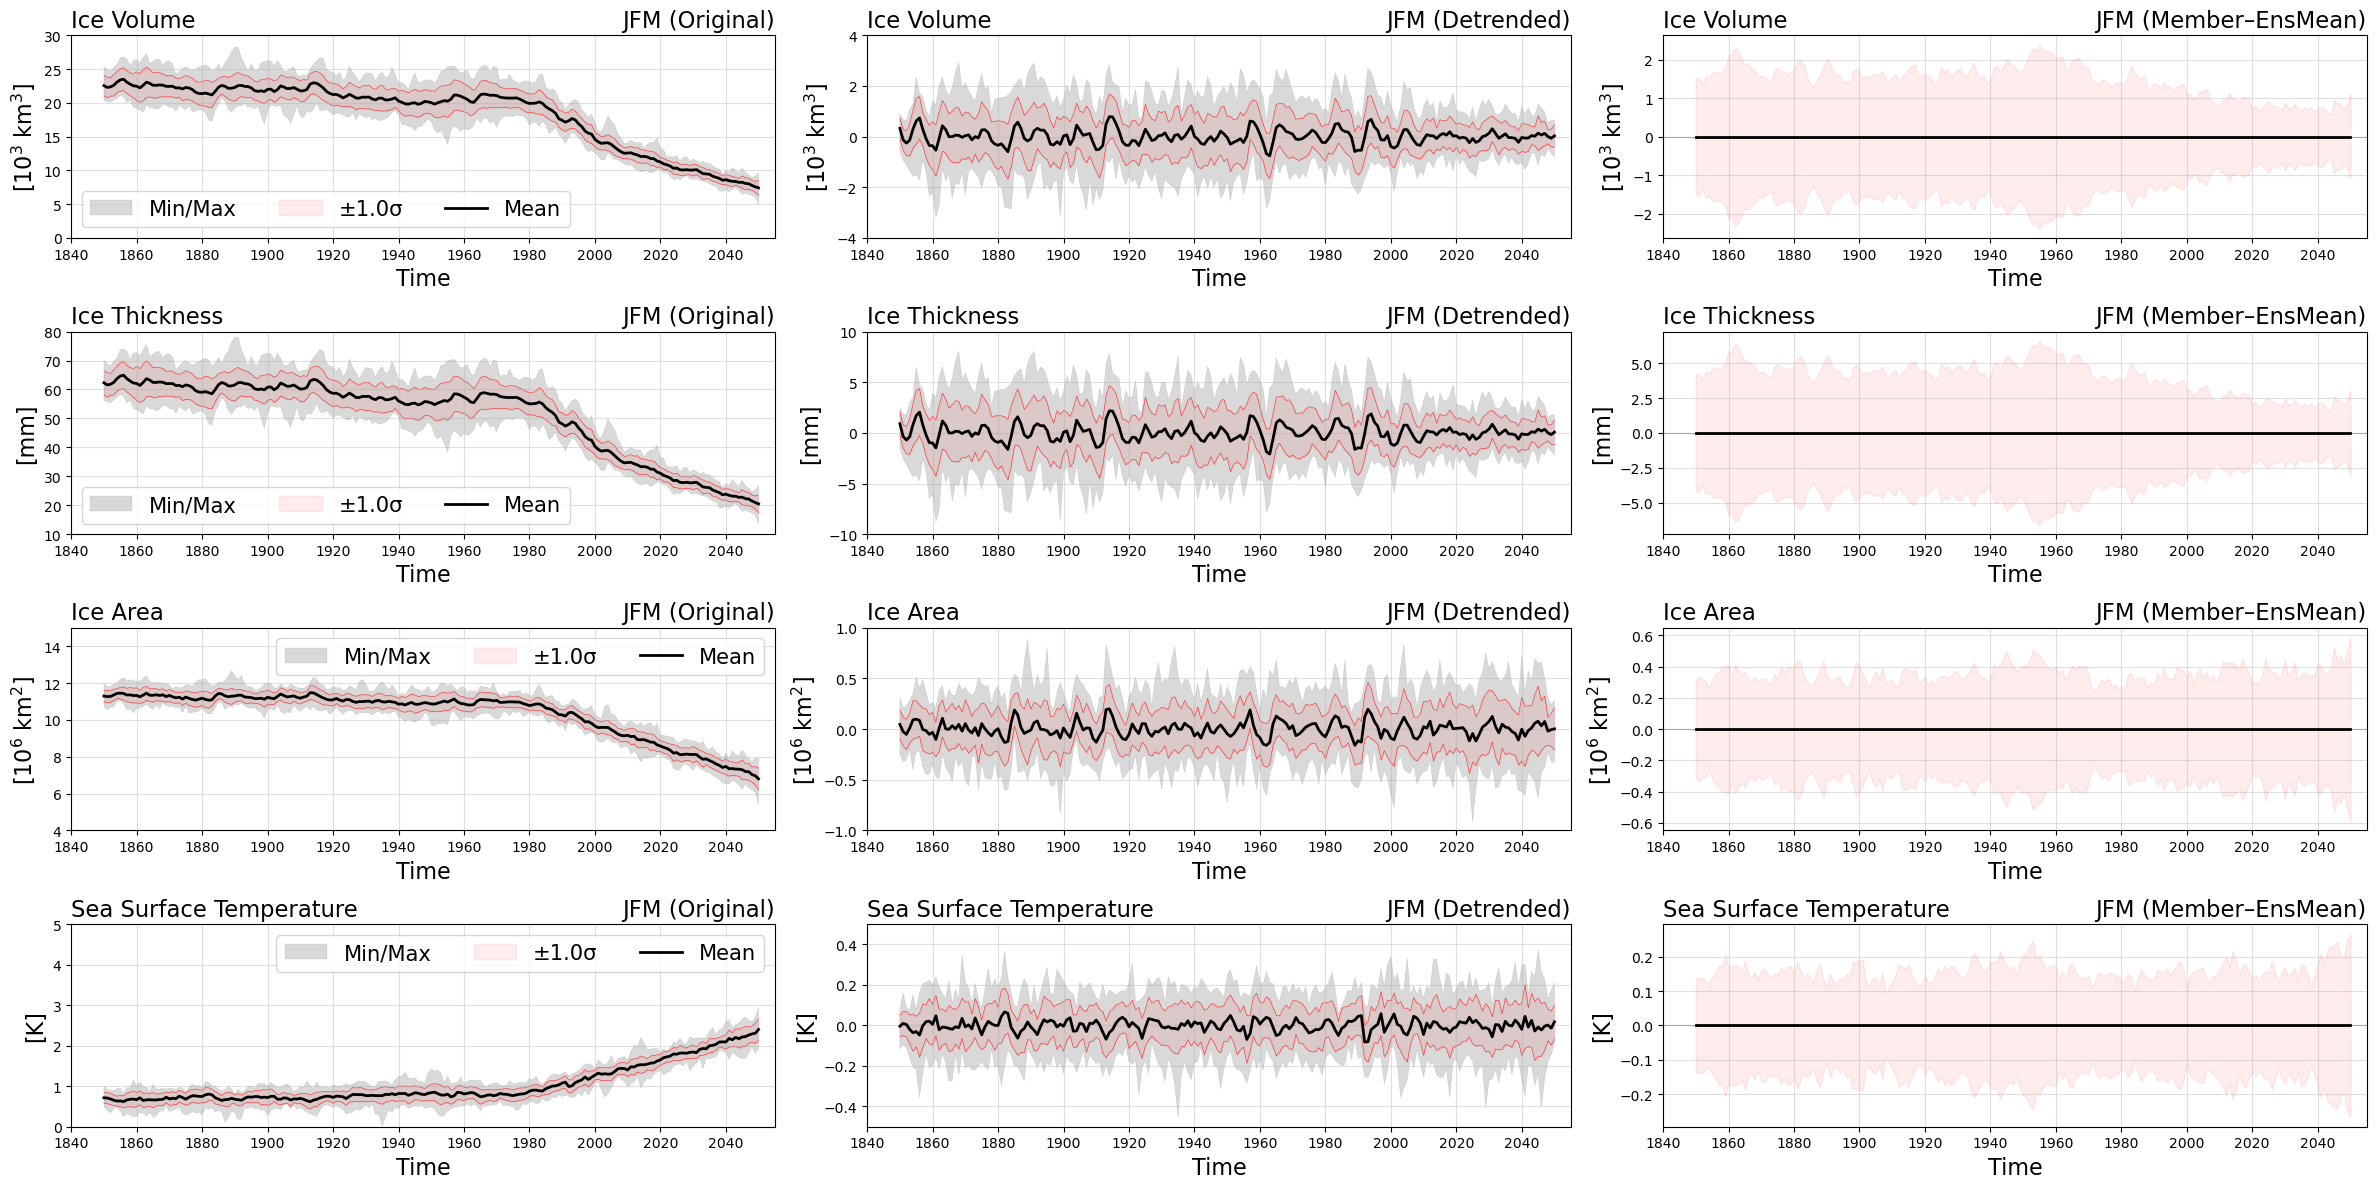

[INFO] Saved: v3.LR.historical.Arctic.JFM.185001-205012.nens25.pdf


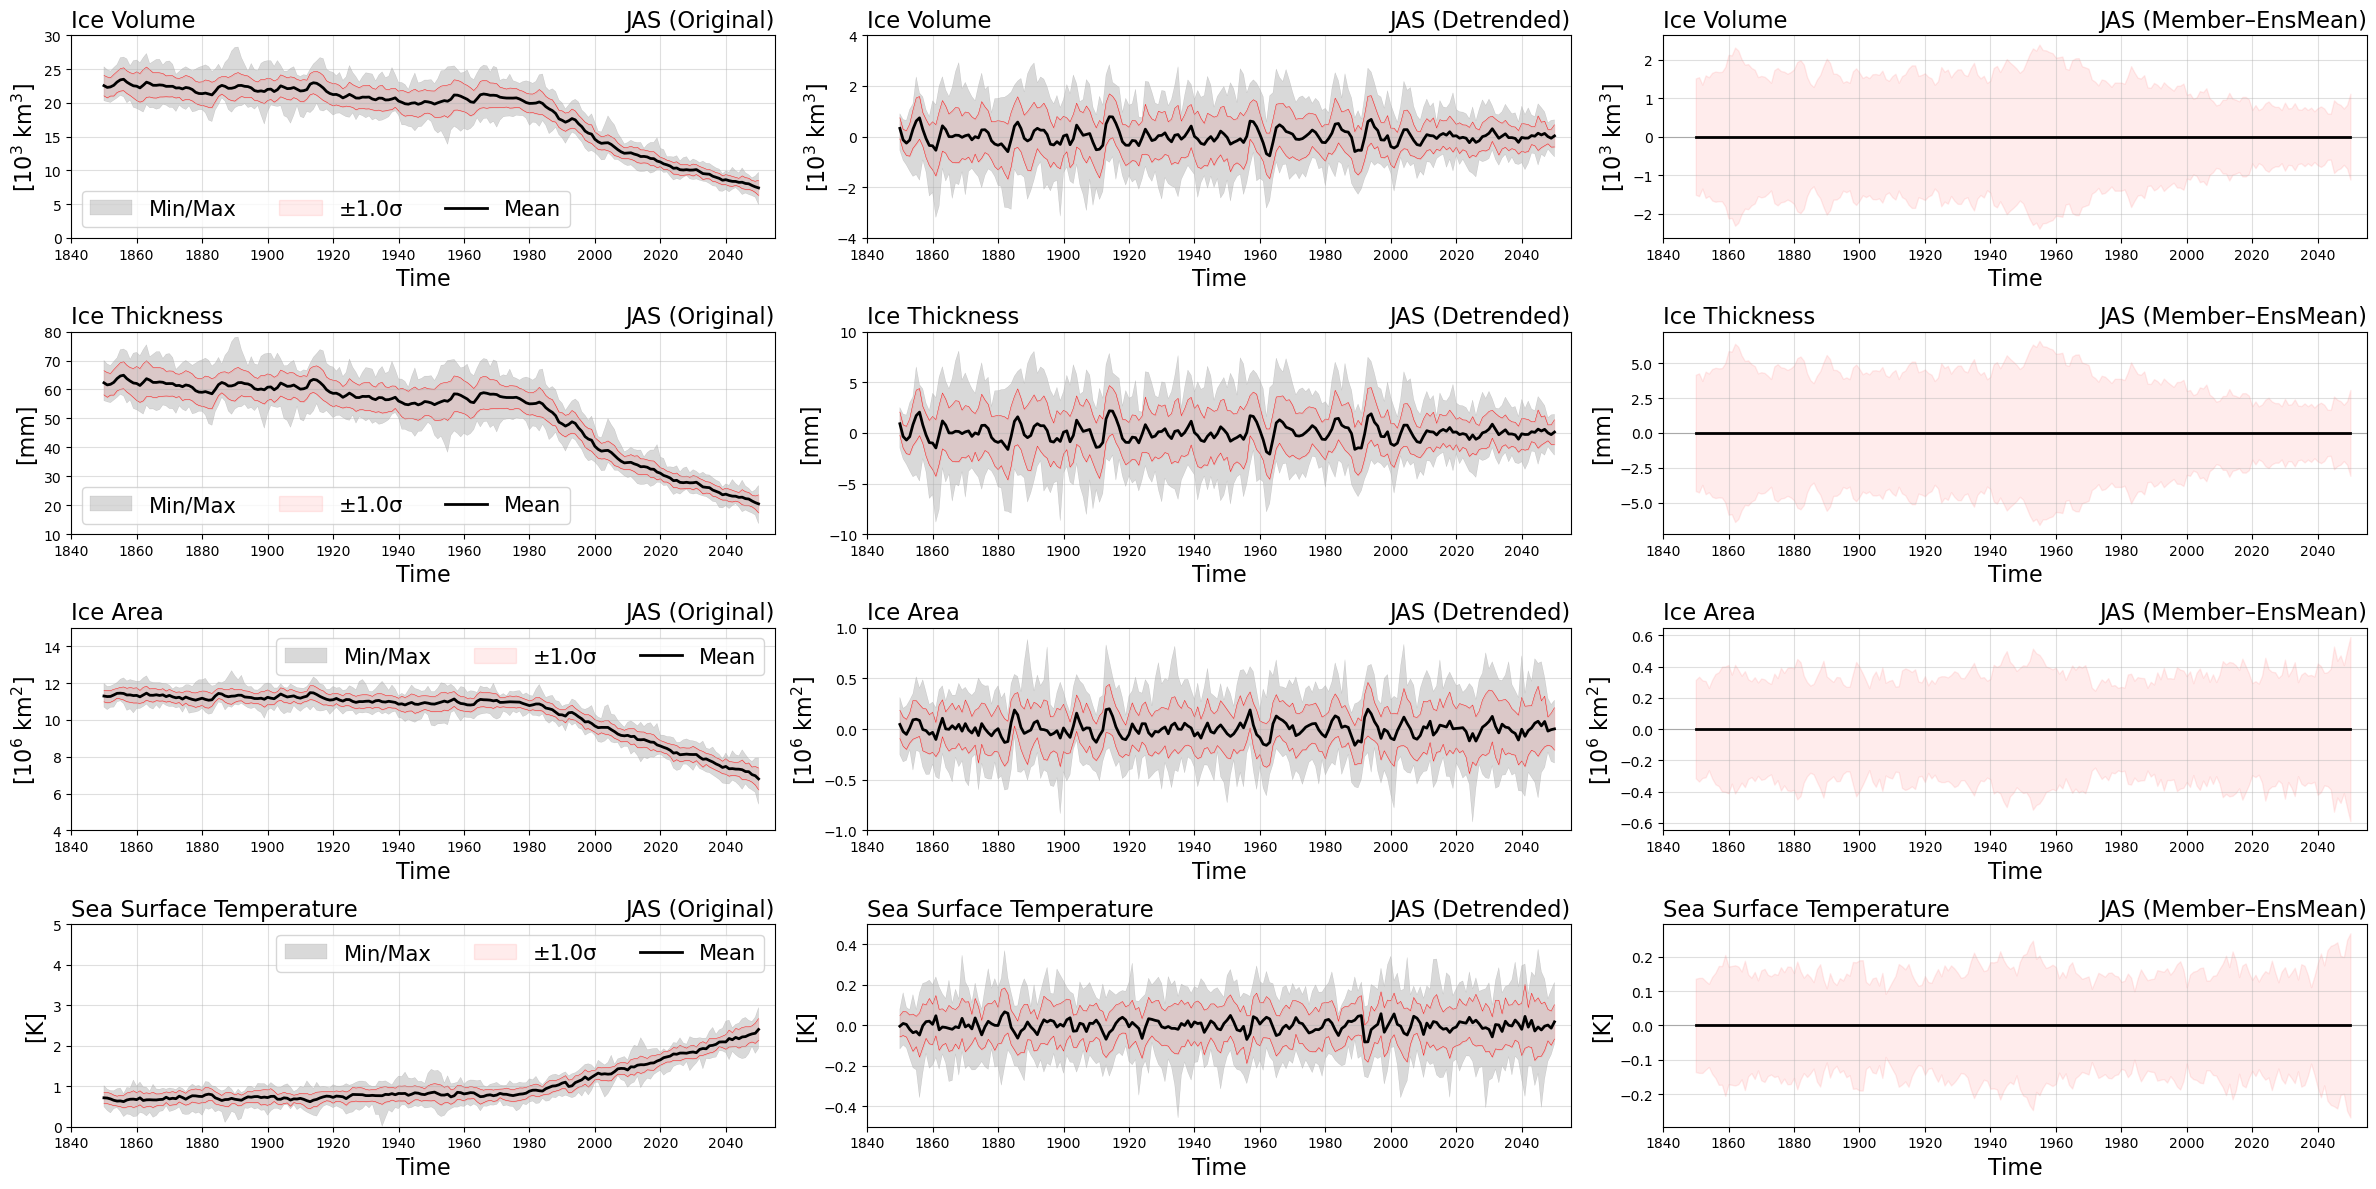

[INFO] Saved: v3.LR.historical.Arctic.JAS.185001-205012.nens25.pdf


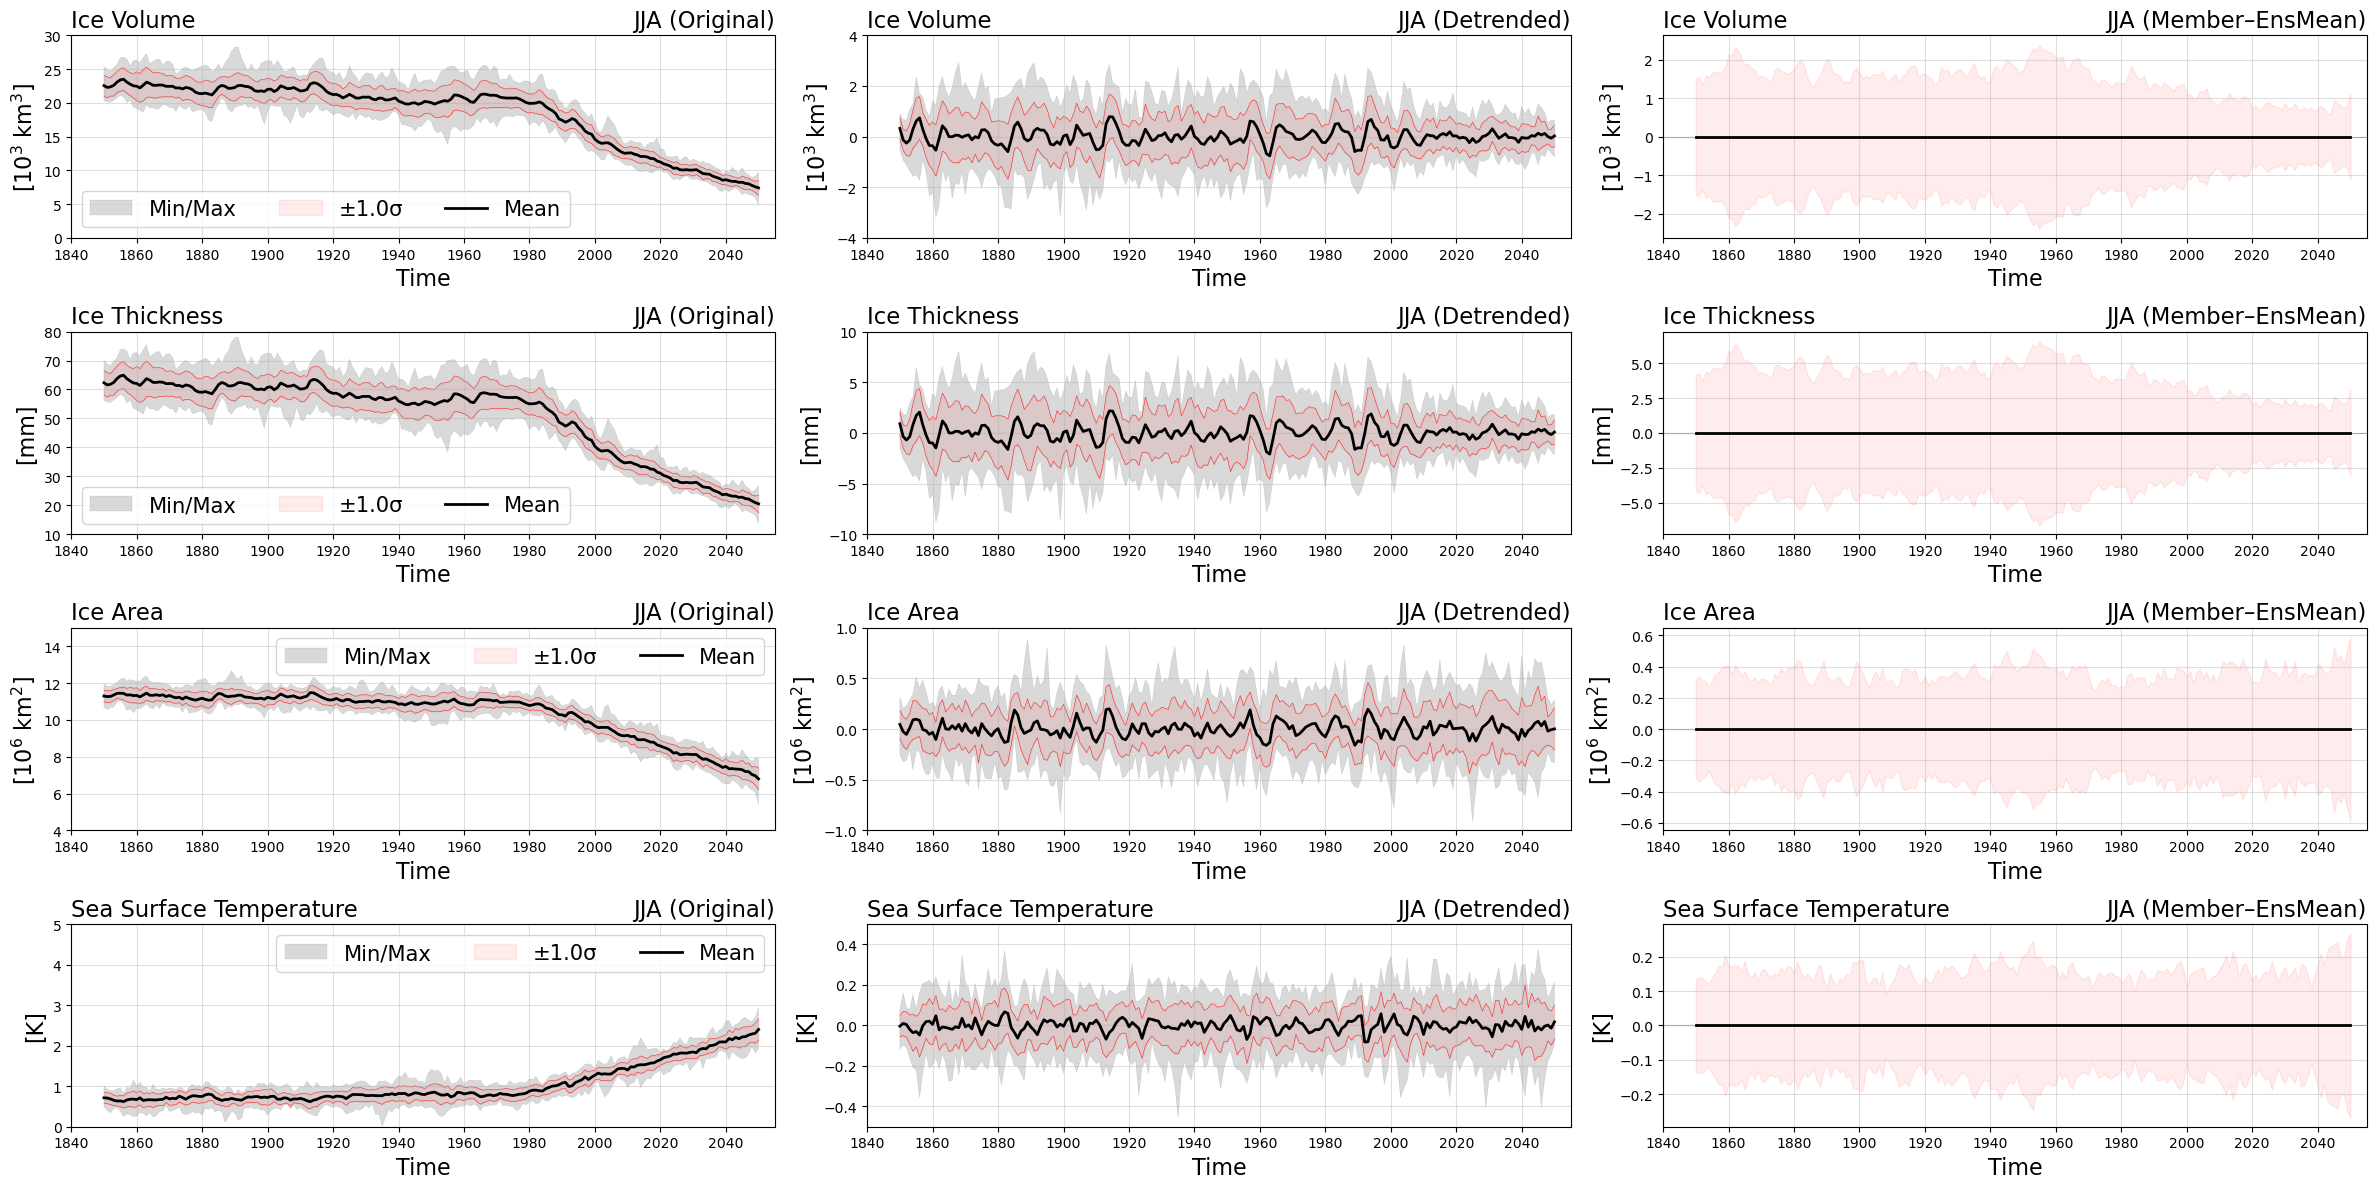

[INFO] Saved: v3.LR.historical.Arctic.JJA.185001-205012.nens25.pdf


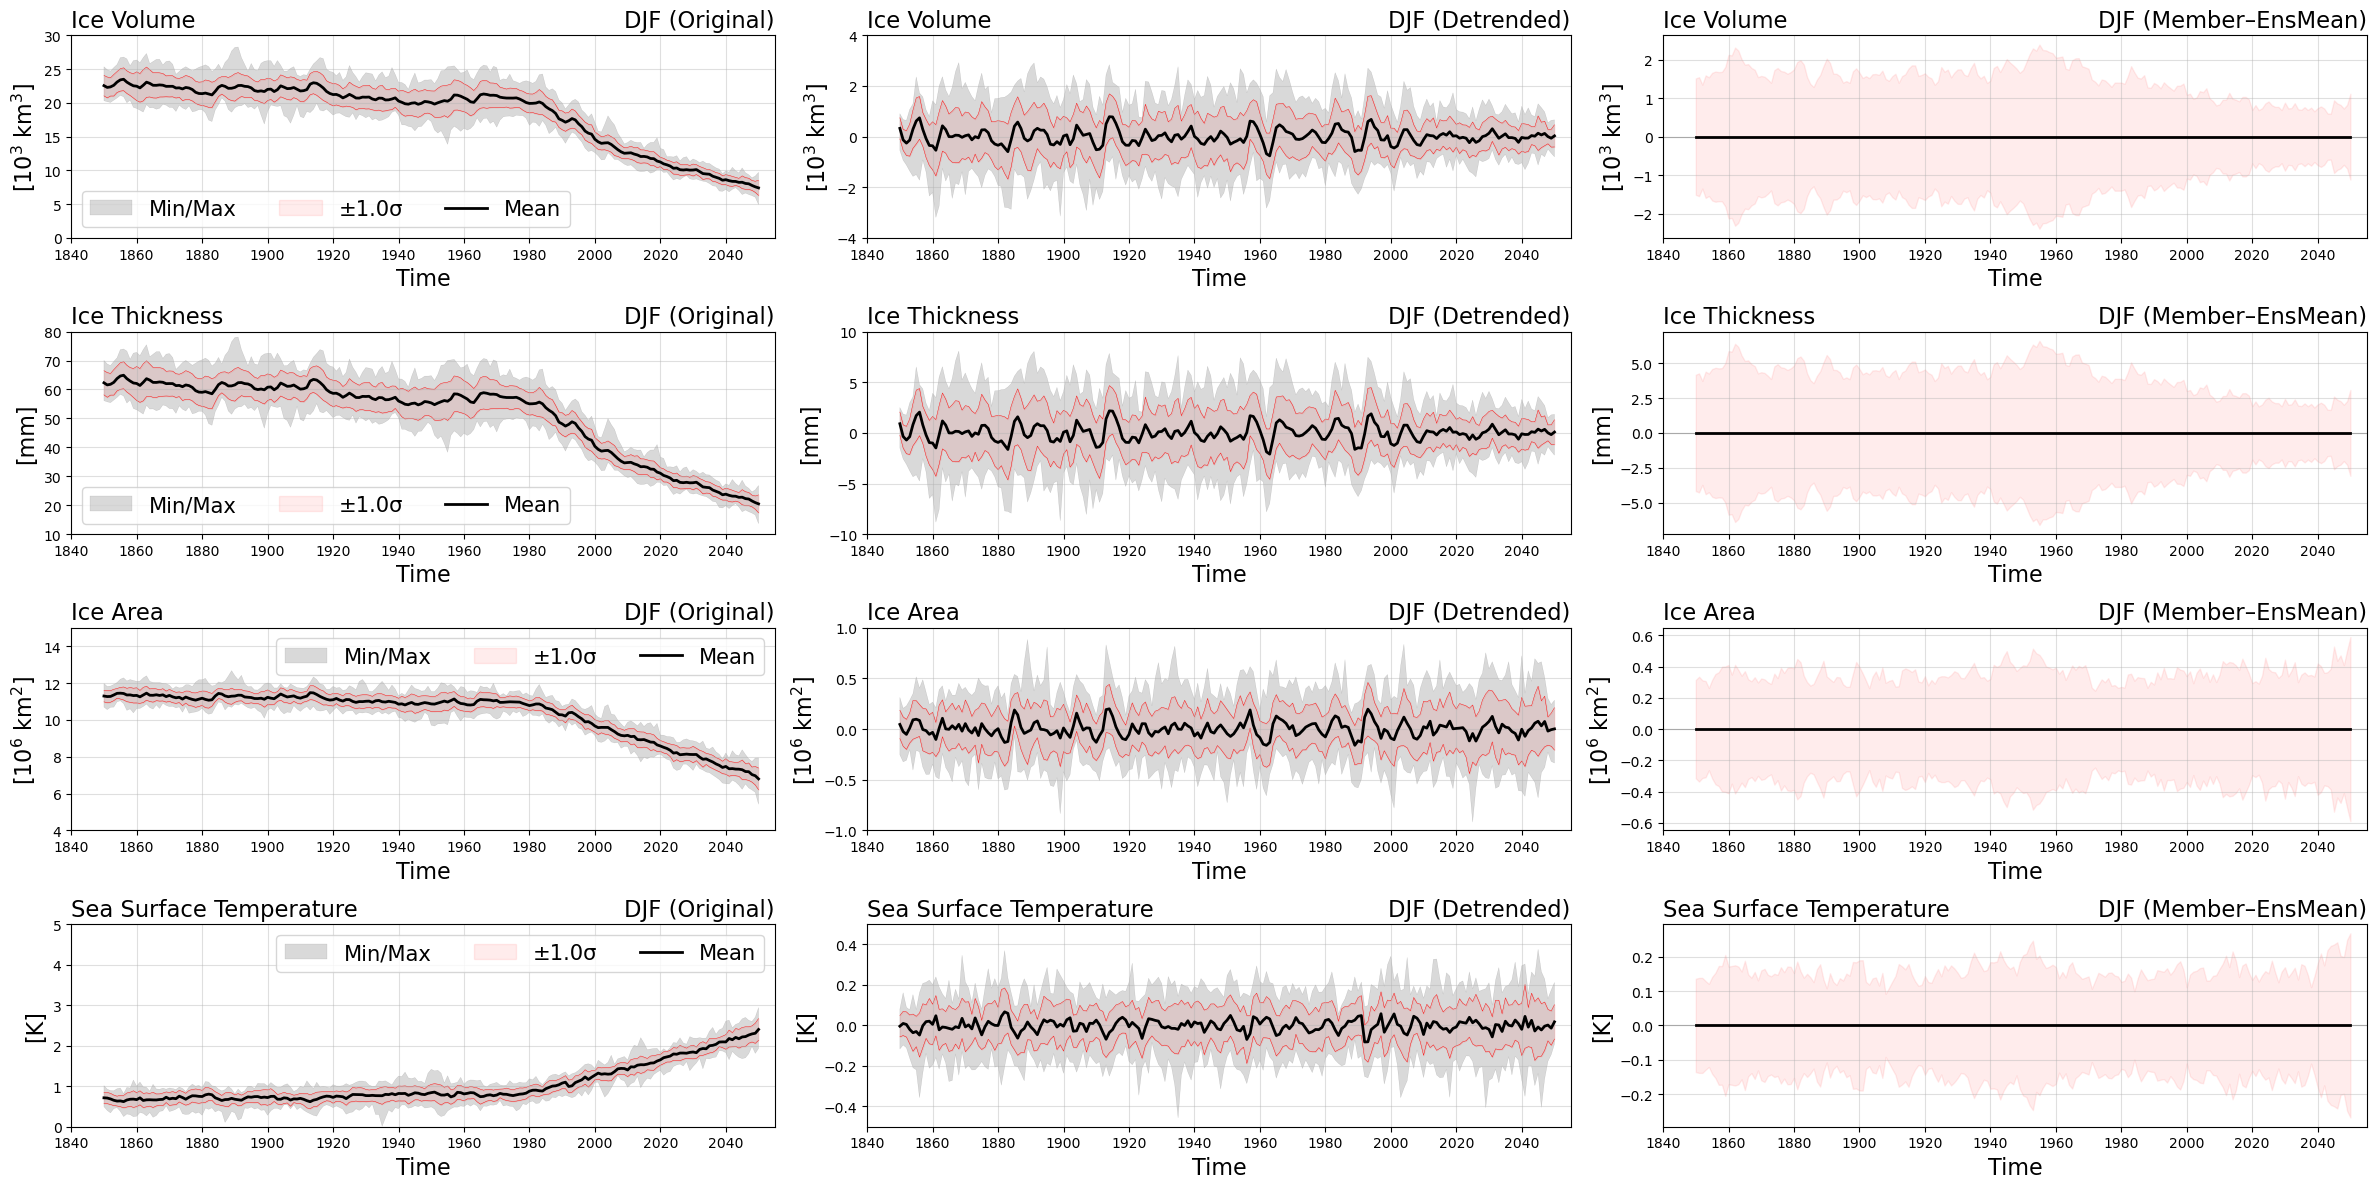

[INFO] Saved: v3.LR.historical.Arctic.DJF.185001-205012.nens25.pdf


In [6]:
if __name__ == "__main__":
    # --- Paths
    top_dir  = "/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/large_ensemble"
    data_dir = f"{top_dir}/data/sea_ice"
    fig_dir  = str(FIG_DIR_ROOT)  # where PDFs go
    Path(fig_dir).mkdir(parents=True, exist_ok=True)

    # --- Ensemble naming / meta
    group   = "v3.LR.historical"
    regnam  = "Arctic"
    nens    = 25
    engine  = "netcdf4"
    assert isinstance(nens, int) and nens > 0, "nens must be a positive integer"
    period  = "1850-2050"
    
    xmin = int(period.split("-")[0])
    xmax = int(period.split("-")[1])
    
    start_year, end_year = period.split("-")
    date_span = f"{start_year}01-{end_year}12"
    detrend_window = 10  # yrs
    if detrend_window is not None:
        assert int(detrend_window) >= 3, "Use a detrend window ≥ 3 years for stability"
        
    month_map = {
        "MAM":   [3, 4, 5],
        "JJA":   [6, 7, 8],
        "SON":   [9, 10, 11],
        "DJF":   [12, 1, 2],
        "Freeze":[10, 11, 12, 1, 2, 3],
        "Melt":  [4, 5, 6, 7, 8, 9],
        "Growth":[10, 11, 12],
        "Decay": [4, 5, 6],
        "JAS":   [7, 8, 9],
        "JFM":   [1, 2, 3],
        "ANN":   list(range(1, 13)),
    }
        
    # --- Variables (units appear in y-labels)
    var_typ = "raw"   # (unused here, kept for consistency)
    var_key = ""

    overrides = {
        "iceVolume": {
            "name": "Ice Volume", 
            "unit": r"10$^3$ km$^3$", 
            "min": 0, "max": 30, 
            "dmin": -4, "dmax": 4, 
            "nlev": 11, "scale": 1e-12
        },
        "iceThickness": {
            "name": "Ice Thickness", 
            "unit": "mm",
            "min": 10, "max": 80, 
            "dmin": -10, "dmax": 10, 
            "nlev": 11, "scale": 1e3
        },
        "iceArea": {
            "name": 
            "Ice Area", 
            "unit": r"10$^6$ km$^2$",
            "min": 4, "max": 15, 
            "dmin": -1, "dmax": 1, 
            "nlev": 11, 
            "scale": 1e-12
        },
        "sst": {
            "name": "Sea Surface Temperature",
            "unit": "K", 
            "min": 0, "max": 5,
            "dmin": -0.5, "dmax": 0.5, 
            "nlev": 11, "scale": 1.0,
            "regidx": 6
        },
    }

    try:
        base_dict = REFERENCE_VAR_DICT.copy()
    except NameError:
        base_dict = {}
    var_dict = {**base_dict, **overrides}

    # Subset for plotting
    sub_keys = ["iceVolume", "iceThickness", "iceArea", "sst"]
    sub_dict = {k: var_dict[k] for k in sub_keys if k in var_dict}
    if not sub_dict:
        raise ValueError("No matching variables found in var_dict for sub_keys!")

    # --- Plot style
    spread = "std"
    sigma = 1.0
    rolling = None
    separate_panels = True
    use_detrended = True
    add_ensanom = True
    ylim = "bounds"
    xlim = (xmin-5,xmax+5)
    
    whiskers = {
        "type": "minmax", "line_pat": "-", "line_thk": 0.3, "line_col": "black",
        "percentile": (5, 95), "show_band": True, "hatch_type": "", "fill_alpha": 0.15,
    }
    
    pct_band=(5, 95)
    sharey = False
    main_title=False
    xlabels="all"

    dpi, line_color, fill_color = 600, "black", "red"
    fontz, fig_width, panel_height = 16, 24.0, 3.0
    row_space, col_space = 0.6, 0.2
    enstr = f"{nens:02d}"

    # Where your precomputed stats live (produced by the processor phase)
    stats_root = V3LE_DIAG_DIR

    for season in ["ANN","JFM", "JAS", "JJA", "DJF"]:
        if season not in month_map.keys():
            raise ValueError(f"Unexpected season '{season}'")

        # Path to the precomputed stats for this season
        stats_nc = stats_root / f"{group}.{regnam}.{season}.ensemble_stats.{date_span}.nc"
        if not stats_nc.is_file():
            raise FileNotFoundError(f"Missing stats NetCDF for plotting: {stats_nc}")

        # Put season plots in a subfolder for tidiness
        out_path =  Path(fig_dir) / f"{group}.{regnam}.{season}.{date_span}.nens{enstr}.pdf"
        
        # Create plotter
        plotter = AnnualAnomalyFigurePlotter(
            stats_ds_or_path=str(stats_nc),
            var_dict=var_dict,
            season=season,
            fontz=fontz,
            fig_dir=fig_dir,
        )

        # Render figure from the precomputed stats (no full processing here)
        plotter.plot(
            sub_dict=sub_dict,
            spread=spread,
            sigma=sigma,
            pct_band=pct_band,
            separate_panels=separate_panels,
            use_detrended=use_detrended,
            add_ensanom=add_ensanom,
            dpi=dpi,
            fig_width=fig_width,
            panel_height=panel_height,
            row_space=row_space,
            col_space=col_space,
            line_color=line_color,
            fill_color=fill_color,
            whiskers=whiskers["type"],
            whisker_pct=whiskers["percentile"],
            whisker_color=whiskers["line_col"],
            whisker_alpha=whiskers["fill_alpha"],
            whisker_linewidth=whiskers["line_thk"],
            whisker_hatch=whiskers["hatch_type"],
            ylim=ylim,
            xlim=xlim,
            sharey=sharey,
            xlabels=xlabels,
            out_path=str(out_path),
            main_title=main_title,
        )
